# RFSoC-PYNQ Multi-Tile Sync Acquisition Design
---

This notebook is based on Xilinx [RFSoC-MTS](https://github.com/Xilinx/RFSoC-MTS/blob/main/boards/ZCU208/notebooks/rfsocMTS.ipynb).

This overlay provides one DAC player memory that is broadcast to multiple RF DAC tiles. DACs in use are Tiles 228 and 229. Tile 230, while enabled, only shares the reference 4GHz to Tiles 228 and 229.  ADC tiles 224 and 225 capture to internal memories.  ADC tile 225 channel 1 stores to the PL DRAM via DMA.  A simplified block diagram is presented below.

The following results were captured when looping back DAC 0 -> ADC 0, and DAC 2 -> ADC 2.


### Preparation from a PYNQ 3.0.1 image:

1. Patch xrfdc to version 2.0 for enabling MTS following the [installation script](https://github.com/Xilinx/RFSoC-MTS/blob/main/install.sh).
2. Install `xrfclk` TICS files for testing frequency settings: 4.0 Gsps for DAC and ADC.
    ```
    sudo cp RFSoC-MTS/doc/clk104/external_mo/*.txt* /usr/local/share/pynq-venv/lib/python3.10/site-packages/xrfclk/
    ```
3. Expect the following files in `/home/xilinx/jupyter_notebooks/RFSoC-MTS/rfsoc_mts`:
    * `ddr4.dtbo`: built by `install.sh` via device tree compiler
    * `mts.ZCU208.bit` and `mts.ZCU208.hwh` after executing `download_overlays()` in the follwing step.

In [1]:
%cd 'RFSoC-MTS'
%pwd

[Errno 2] No such file or directory: 'RFSoC-MTS'
/home/xilinx/jupyter_notebooks/RFSoC-MTS


'/home/xilinx/jupyter_notebooks/RFSoC-MTS'

In [2]:
from scipy import signal
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = [8, 5]
plt.rcParams['axes.grid'] = True
plt.rcParams['axes.grid.which'] = "both"
plt.rcParams['grid.linewidth'] = 0.5
plt.rcParams['grid.alpha'] = 0.5
plt.rcParams['font.size'] = 8

In [3]:
from pathlib import Path
from pynqutils.setup_utils import download_overlays
import os

bit_file = Path('./rfsoc_mts/mts.bit.d/mts.ZCU208.bit')
hwh_file = Path('./rfsoc_mts/mts.hwh.d/mts.ZCU208.hwh')

if not bit_file.is_file() or not hwh_file.is_file():
    download_overlays(path='./')
    os.symlink(bit_file, 'mts.bit')
    os.symlink(hwh_file, 'mts.hwh')

In [4]:
DAC_SR = 4.0e9  # Sample rate of DACs and ADCs is 4.0 GHz
ADC_SR = 4.0e9

def plot_adc_wfm(cdata, fs=ADC_SR, width=10, height=3):
    fs /= 1e9
    n_ch, n_samples = cdata.shape
    t = np.arange(0, n_samples/fs, 1/fs)
    fig, axes = plt.subplots(
        n_ch, sharex=True, figsize=(width, n_ch*height))
    for i, (wfm, ax) in enumerate(zip(cdata, axes)):
        ax.plot(t, wfm, label=f'chan {i} ')
        ax.set_title(f'chan {i} ')
        ax.legend()
        ax.set_xlabel('Time [ns]')

def plot_adc_psd(wfm, fs=ADC_SR, onsided=True, width=10, height=4):
    f, pxxs = signal.periodogram(
        wfm, fs, 'flattop', scaling='spectrum',
        return_onesided=onsided)
    if not onsided:
        f = np.fft.fftshift(f)
        pxxs = np.fft.fftshift(pxxs, axes=1)
    n_ch, n_samples=wfm.shape
    fig, axes = plt.subplots(
        n_ch, sharex=True, figsize=(width, n_ch*height))
    for i, (pxx, ax) in enumerate(zip(pxxs, axes)):
        ax.plot(f, 10*np.log10(pxx))
        f_peak = f[np.argmax(pxx)]
        ax.set_title(f'ADC {i}, peak: {f_peak/1e6:.3f} MHz ')
        ax.set_xlabel('Freq [MHz]')
        ax.set_ylabel('Power [dBFS]')

In [5]:
from rfsoc_mts import mtsOverlay
ol = mtsOverlay('mts.bit')

Addr 0x147: val = 0x4a; clkin = clkin4 (INVALID)


In [6]:
import xrfclk
xrfclk.set_ref_clks(lmk_freq=499.63, lmx_freq=3997.11)

Addr 0x147: val = 0xa; clkin = clkin0 (ext)


In [7]:
import xrfdc

dac_blocks = [
    ol.xrfdc.dac_tiles[0].blocks[0],
    ol.xrfdc.dac_tiles[0].blocks[2],
    ol.xrfdc.dac_tiles[1].blocks[0],
    ol.xrfdc.dac_tiles[1].blocks[2],
]

adc_blocks = [
    ol.xrfdc.adc_tiles[0].blocks[0],
    ol.xrfdc.adc_tiles[0].blocks[1],
    ol.xrfdc.adc_tiles[1].blocks[0],
    ol.xrfdc.adc_tiles[1].blocks[1],
]

def set_dac_mixer_dco(freq_mhz=500, nyquist=1):
    for dac_block in dac_blocks:
        dac_block.NyquistZone = nyquist
        dac_block.MixerSettings = {
            'Freq': freq_mhz,
            'EventSource': xrfdc.EVNT_SRC_SYSREF,
            'CoarseMixFreq': xrfdc.COARSE_MIX_BYPASS,
            'PhaseOffset': 0,
            'MixerMode': xrfdc.MIXER_MODE_C2R,
            'MixerType': xrfdc.MIXER_TYPE_FINE
        }

def set_adc_mixer_dco(freq_mhz=500, nyquist=1):
    for adc_block in adc_blocks:
        adc_block.NyquistZone = nyquist
        adc_block.MixerSettings = {
            'Freq': freq_mhz,
            'EventSource': xrfdc.EVNT_SRC_SYSREF,
            'CoarseMixFreq': xrfdc.COARSE_MIX_BYPASS,
            'PhaseOffset': 0,
            'MixerMode': xrfdc.MIXER_MODE_R2C,
            'MixerType': xrfdc.MIXER_TYPE_FINE
        }

In [8]:
from pynq import Clocks

print(f'CPU:   {Clocks.cpu_mhz:10.3f} MHz')
print(f'FCLK0: {Clocks.fclk0_mhz:10.3f} MHz')
print(f'FCLK1: {Clocks.fclk1_mhz:10.3f} MHz')
print(f'FCLK2: {Clocks.fclk2_mhz:10.3f} MHz')
print(f'FCLK3: {Clocks.fclk3_mhz:10.3f} MHz')

CPU:     1199.988 MHz
FCLK0:     99.999 MHz
FCLK1:     99.999 MHz
FCLK2:     99.999 MHz
FCLK3:     99.999 MHz


# Generate Waveforms for Loopback
 This overlay uses a single waveform memory that is broadcast to multiple DAC tiles.
### Prepare the DAC Memory
The cell below generates examples waveforms and has customizable paramters.  For example, one can adjust the center frequency, Fc, and re-generate a sinewave.

In [9]:
Fc = 250.0E6
amp = (1 << 14) - 1
n_samples = ol.dac_player.size
t_axis = np.arange(n_samples) / DAC_SR
DAC_sinewave = amp * np.sin(2 * np.pi * Fc * t_axis)

In [10]:
set_dac_mixer_dco(0)
ol.dac_player[:] = np.int16(DAC_sinewave)

---

## Capture DAC Waveform to Internal Memory
The DAC waveform is saved to an internal memory for verification purposes.

In [11]:
ol.trigger_capture()
df_dac = pd.DataFrame({
    'Time [ns]': t_axis * 1e9,
    'dac_player': ol.dac_player,
    'dac_capture': ol.dac_capture
})
df_dac.set_index('Time [ns]');

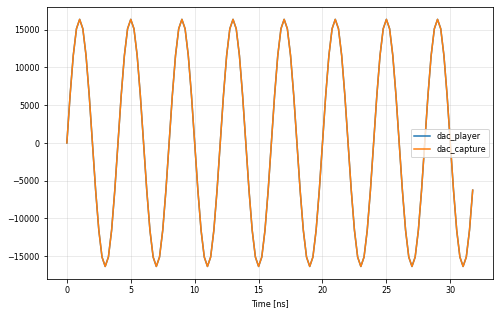

In [12]:
df_dac[:128].plot(x='Time [ns]');

---

In [13]:
def stemplot(sample_list, pStart=0, pNumSamples=16):
    plt.stem(sample_list[0][pStart:(pStart+pNumSamples)])
    plt.stem(sample_list[1][pStart:(pStart+pNumSamples)], linefmt='r:', markerfmt='rx')
    plt.stem(sample_list[2][pStart:(pStart+pNumSamples)], linefmt='g-', markerfmt='g+')
    plt.tight_layout()
    return plt

def gridplot(sample_list, pStart=0, pNumSamples=128):
    plt.subplots(3,1)
    plt.subplot(311)
    plt.plot(sample_list[0][pStart:(pStart+pNumSamples)])
    plt.subplot(312)
    plt.plot(sample_list[1][pStart:(pStart+pNumSamples)])
    plt.subplot(313)
    plt.plot(sample_list[2][pStart:(pStart+pNumSamples)])
    plt.tight_layout()
    return plt

---

# Enable Multi-Tile Synchronization - MTS
With Multi-Tile Synchronization enabled the DAC output and ADC samples are aligned.  This feature of the RFSOC allows coherency across DAC and ADC tiles.  The RF tiles are reset and their internal FIFOs reset via "init_tile_sync" while also testing if the synthesizer clocks are ready.  Once initialized, the "sync_tiles" function begins the synchronization procedure of the tiles. The results are analyzed below.

In [14]:
ol.init_tile_sync()
ol.verify_clock_tree()
ol.sync_tiles()

In [15]:
AlignedCaptureSamples = np.zeros((3,len(ol.adc_capture_chA)),dtype=np.int16)

In [16]:
ol.internal_capture(AlignedCaptureSamples)

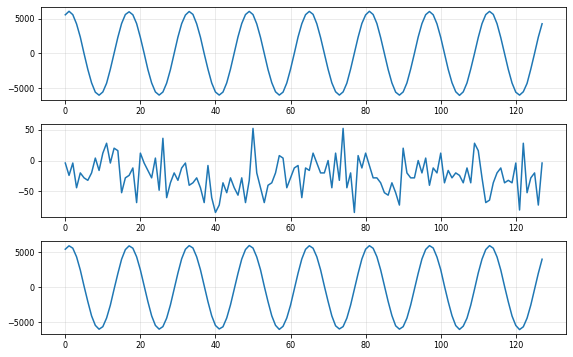

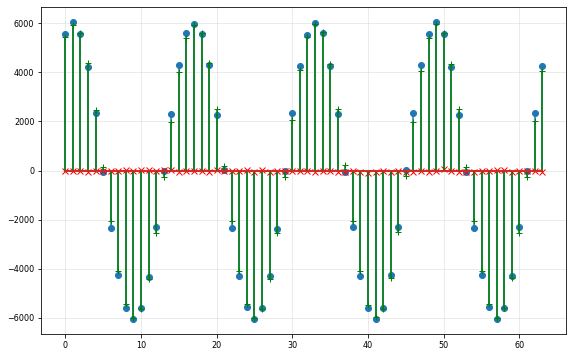

In [17]:
gridplot(AlignedCaptureSamples, pStart=0, pNumSamples=128).show()
stemplot(AlignedCaptureSamples, pStart=0, pNumSamples=64).show()

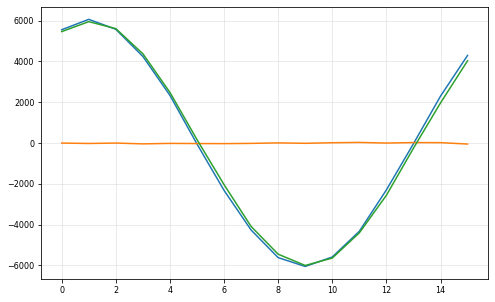

In [18]:
pStart = 0
pNumSamples = 16
plt.plot(AlignedCaptureSamples[0][pStart:(pStart+pNumSamples)])
plt.plot(AlignedCaptureSamples[1][pStart:(pStart+pNumSamples)])
plt.plot(AlignedCaptureSamples[2][pStart:(pStart+pNumSamples)])
plt.show()

## Latency Incurred Due To Alignment
Enabling MTS adds additional latency in the received sample datapath.  Due to the alignment process one or more streams will be delayed N number of samples and that is reported below in the "Latency Reporting".

In [19]:
print("Latency DAC Tile 0: ", ol.xrfdc.mts_dac_config.Latency[0])
print("Latency DAC Tile 1: ", ol.xrfdc.mts_dac_config.Latency[1])
print("Latency ADC Tile 0: ", ol.xrfdc.mts_adc_config.Latency[0])
print("Latency ADC Tile 1: ", ol.xrfdc.mts_adc_config.Latency[1])

Latency DAC Tile 0:  120
Latency DAC Tile 1:  120
Latency ADC Tile 0:  11
Latency ADC Tile 1:  11


---
## Mixer test

Set DAC waveform to DC as amplitude control.
Set DAC mixer to fine mixer mode.
Readback ADC waveforms, expecting zero readout due to AC coupling.

In [20]:
n_samples = ol.dac_player.size
ol.dac_player[:] = np.ones(n_samples, dtype=np.int16) * 32767
set_dac_mixer_dco(0)

Looped back ADC got zero reading.

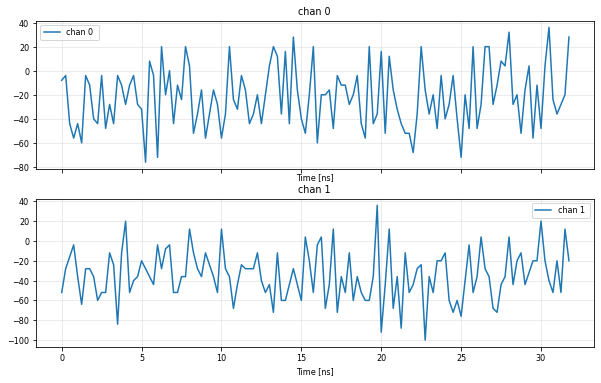

In [21]:
ol.internal_capture(AlignedCaptureSamples)
plot_adc_wfm(AlignedCaptureSamples[::2, :128])

### Change DAC mixer setting with NCO to 500MHz

In [22]:
set_dac_mixer_dco(500)
ol.init_tile_sync()
ol.verify_clock_tree()
ol.sync_tiles()

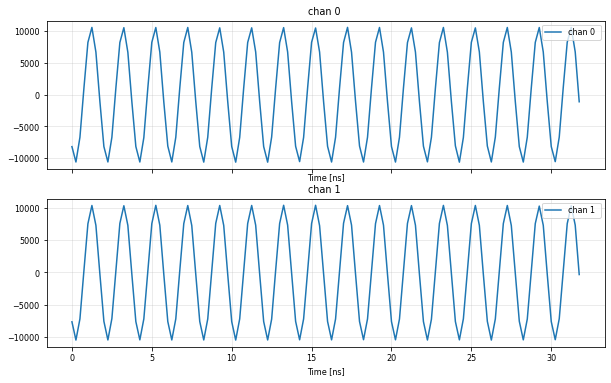

In [23]:
ol.internal_capture(AlignedCaptureSamples)
plot_adc_wfm(AlignedCaptureSamples[::2, :128])

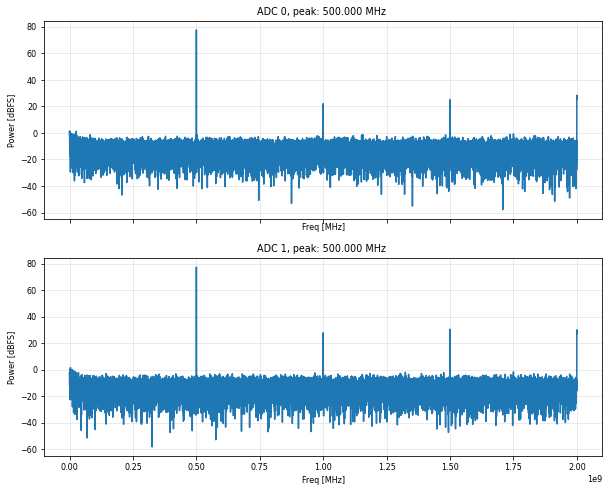

In [24]:
plot_adc_psd(AlignedCaptureSamples[::2])

Looped back ADC got 500MHz due to mixer upconversion.

### Test ADC mixer

Set ADC DCO to 550MHz, expect tones at 50MHz, 1050MHz, etc.

In [25]:
set_adc_mixer_dco(550)

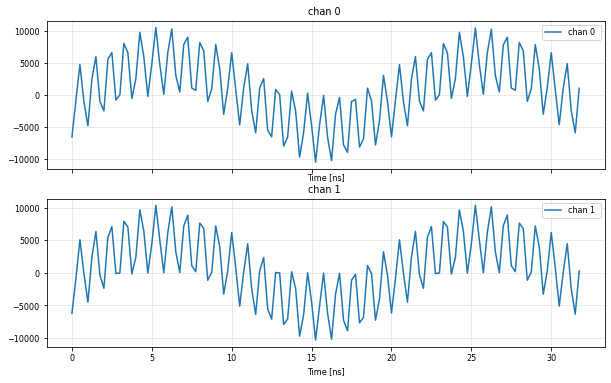

In [26]:
ol.internal_capture(AlignedCaptureSamples)
plot_adc_wfm(AlignedCaptureSamples[::2, :128])

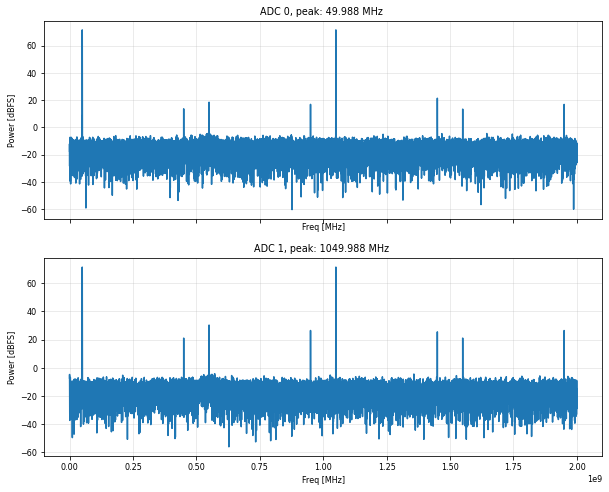

In [27]:
plot_adc_psd(AlignedCaptureSamples[::2])

In [28]:
set_adc_mixer_dco(0)

### Change DAC mixer setting with NCO to 125MHz

In [29]:
set_dac_mixer_dco(125)

ol.init_tile_sync()
ol.verify_clock_tree()
ol.sync_tiles()

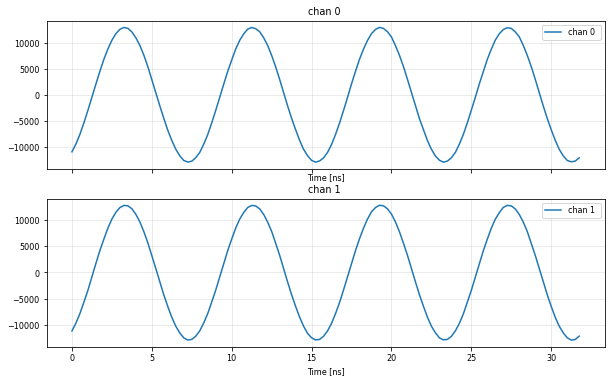

In [30]:
ol.internal_capture(AlignedCaptureSamples)
plot_adc_wfm(AlignedCaptureSamples[::2, :128])

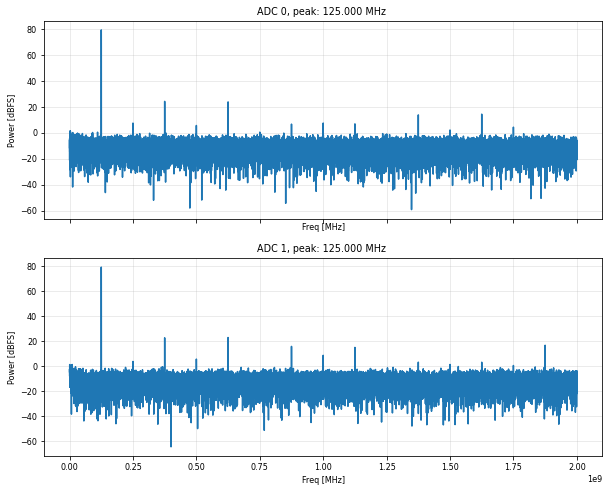

In [ ]:
plot_adc_psd(AlignedCaptureSamples[::2])

### Change DAC mixer setting with NCO to 3000MHz

PG269, Figure 27 (b): NCO = -Fc for upconversion to even Nyquist band

In [35]:
set_dac_mixer_dco(-3000, nyquist=2)
ol.init_tile_sync()
ol.verify_clock_tree()
ol.sync_tiles()

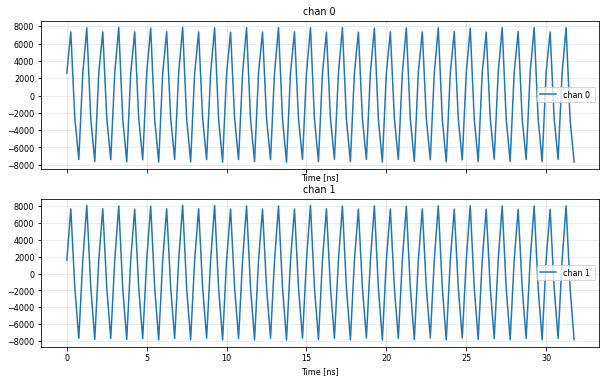

In [37]:
ol.internal_capture(AlignedCaptureSamples)
plot_adc_wfm(AlignedCaptureSamples[::2, :128])

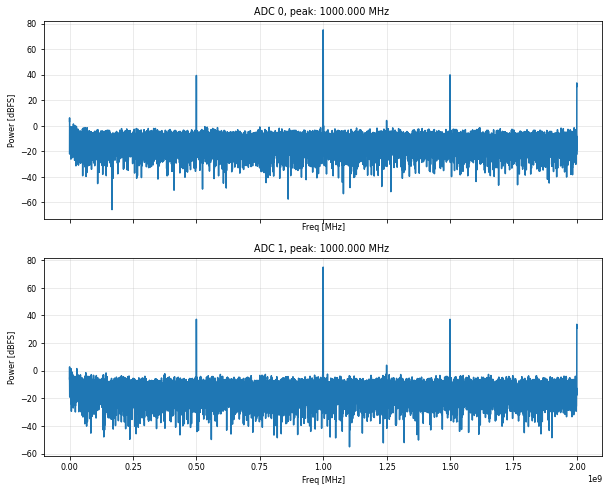

In [38]:
plot_adc_psd(AlignedCaptureSamples[::2])